In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler

# Cargamos el dataset directamente desde URL pública (sin descarga)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dataset: {df.shape[0]} filas, {df.shape[1]} columnas')
print('\nNulos por columna:')
print(df.isnull().sum())
df.head()


Dataset: 891 filas, 12 columnas

Nulos por columna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA

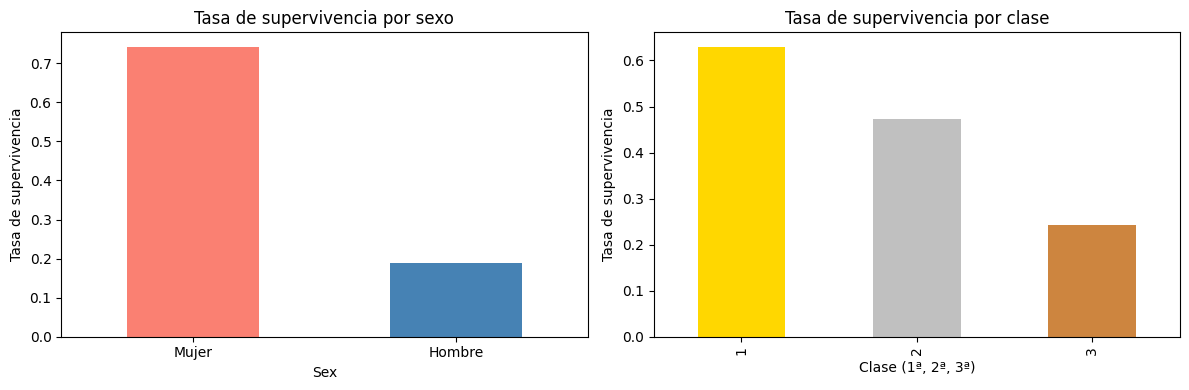

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Supervivencia por sexo
df.groupby('Sex')['Survived'].mean().plot.bar(
    ax=axes[0], color=['salmon','steelblue'],
    title='Tasa de supervivencia por sexo')
axes[0].set_ylabel('Tasa de supervivencia')
axes[0].set_xticklabels(['Mujer','Hombre'], rotation=0)

# Supervivencia por clase
df.groupby('Pclass')['Survived'].mean().plot.bar(
    ax=axes[1], color=['gold','silver','peru'],
    title='Tasa de supervivencia por clase')
axes[1].set_ylabel('Tasa de supervivencia')
axes[1].set_xlabel('Clase (1ª, 2ª, 3ª)')

plt.tight_layout()
plt.show()


# Preprocesado

In [29]:
# ── 1. Separar target y hacer copia ───────────────────────────────────
df_prep = df.copy()
y = df_prep['Survived']

# ── 2. Eliminar columnas sin valor predictivo ──────────────────────────
X = df_prep.drop(columns=['Survived','PassengerId','Name','Ticket','Cabin'])

# ── 3. Imputar nulos ───────────────────────────────────────────────────
# Age: mediana por grupo (Pclass + Sex) — imputación contextual de Clase 5
X['Age'] = X['Age'].fillna(
    X.groupby(['Pclass','Sex'])['Age'].transform('median'))

# Embarked: solo 2 nulos — usamos la moda
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

# ── 4. Codificar variables categóricas ────────────────────────────────
# pd.get_dummies con drop_first para evitar colinealidad perfecta
X = pd.get_dummies(X, columns=["Pclass", "Sex", "Embarked"], drop_first=True)

# ── 5. Escalar variables numéricas ────────────────────────────────────
cols_num = ['Age','Fare','SibSp','Parch']
scaler = StandardScaler()
X[cols_num] = scaler.fit_transform(X[cols_num])

print('Dataset listo para ML:')
print(X.head())
print(f'Shape: {X.shape}')


Dataset listo para ML:
        Age     SibSp     Parch      Fare  Pclass_2  Pclass_3  Sex_male  \
0 -0.534891  0.432793 -0.473674 -0.502445     False      True      True   
1  0.668392  0.432793 -0.473674  0.786845     False     False     False   
2 -0.234070 -0.474545 -0.473674 -0.488854     False      True     False   
3  0.442776  0.432793 -0.473674  0.420730     False     False     False   
4  0.442776 -0.474545 -0.473674 -0.486337     False      True      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  
Shape: (891, 9)


# Lanzamos el modelo

In [30]:
# Dividimos: 80% entrenamiento, 20% evaluación
# stratify=y garantiza la misma proporción de supervivientes en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]} pasajeros  |  Test: {X_test.shape[0]} pasajeros')
print(f'Tasa de supervivencia en train: {y_train.mean()*100:.1f}%')
print(f'Tasa de supervivencia en test:  {y_test.mean()*100:.1f}%')


Train: 712 pasajeros  |  Test: 179 pasajeros
Tasa de supervivencia en train: 38.3%
Tasa de supervivencia en test:  38.5%


In [31]:
y.value_counts(normalize=True)

# Instanciamos el modelo
# max_iter=1000: más iteraciones para asegurar convergencia
# random_state=42: reproducibilidad
modelo = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)


In [32]:
# Entrenamos — fit() aprende los coeficientes β sobre X_train
modelo.fit(X_train, y_train)

# Predecimos sobre el conjunto de TEST (datos que el modelo NUNCA ha visto)
y_pred = modelo.predict(X_test)

# También podemos obtener la probabilidad de supervivencia de cada pasajero
y_prob = modelo.predict_proba(X_test)[:, 1]  # columna 1 = P(sobrevivió)

print('Primeras 10 predicciones:')
print(f'Predicción:   {y_pred[:10]}')
print(f'Probabilidad: {y_prob[:10].round(2)}')
print(f'Real:         {y_test.values[:10]}')


Primeras 10 predicciones:
Predicción:   [0 0 0 0 1 1 1 0 0 0]
Probabilidad: [0.11 0.08 0.25 0.06 0.77 0.54 0.82 0.41 0.46 0.25]
Real:         [0 0 1 0 1 1 1 0 0 0]


# Evaluación

Accuracy: 81.0%
De cada 100 pasajeros, el modelo acierta aproximadamente 81 .


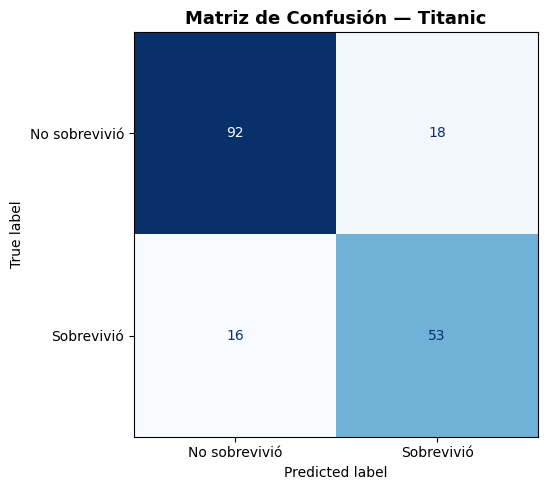


Verdaderos Negativos (TN): 92  — predijo no sobrevivir y era correcto
Falsos Positivos (FP):     18  — predijo sobrevivir pero no sobrevivió
Falsos Negativos (FN):     16  — predijo no sobrevivir pero sí sobrevivió
Verdaderos Positivos (TP): 53  — predijo sobrevivir y era correcto


In [33]:
# ── ACCURACY ────────────────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.1f}%')
print('De cada 100 pasajeros, el modelo acierta aproximadamente', round(acc*100), '.')

# ── MATRIZ DE CONFUSIÓN ─────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No sobrevivió','Sobrevivió'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Titanic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'\nVerdaderos Negativos (TN): {TN}  — predijo no sobrevivir y era correcto')
print(f'Falsos Positivos (FP):     {FP}  — predijo sobrevivir pero no sobrevivió')
print(f'Falsos Negativos (FN):     {FN}  — predijo no sobrevivir pero sí sobrevivió')
print(f'Verdaderos Positivos (TP): {TP}  — predijo sobrevivir y era correcto')


In [34]:
# ── CLASSIFICATION REPORT: todas las métricas de golpe ─────────────────
print('\n── Informe completo de métricas ──')
print(classification_report(y_test, y_pred,
      target_names=['No sobrevivió','Sobrevivió']))



── Informe completo de métricas ──
               precision    recall  f1-score   support

No sobrevivió       0.85      0.84      0.84       110
   Sobrevivió       0.75      0.77      0.76        69

     accuracy                           0.81       179
    macro avg       0.80      0.80      0.80       179
 weighted avg       0.81      0.81      0.81       179

